In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

data = pd.read_csv("phishing_websites.csv")

# Split dataset for training, validation, and testing (60/20/20)

In [2]:
# ensures random sequence is deterministic and reproducible
random_seed = 42

# Features and target
X = data.drop('result', axis = 1)
y = data['result']

# 60/20/20 split for train/validation/test
# First split: 80% train, 20% temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed, stratify=y)

# Second split: 75% of temp (60% of original) train, 25% of temp (20% of original) validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=random_seed, stratify=y_temp)

# XGBoost and Logistic Regression expects labels like 0/1, not -1/1
y_train_binary = (y_train == 1).astype(int)
y_val_binary = (y_val == 1).astype(int)
y_test_binary = (y_test == 1).astype(int)

# Random Forest
----------------------------------------------------------------------------------------------------------------------------------------

In [3]:
# Regularized Random Forest with depth and feature limits to prevent overfitting
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,  # Limit tree depth to prevent overfitting
    min_samples_split=5,  # Require at least 5 samples to split
    min_samples_leaf=2,  # Require at least 2 samples in leaf nodes
    max_features='sqrt',  # Use sqrt(n_features) to reduce correlation between trees
    random_state=random_seed,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Training, validation, and test predictions
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_val = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

# Calculate accuracies
train_acc = accuracy_score(y_train, y_pred_rf_train)
val_acc = accuracy_score(y_val, y_pred_rf_val)
test_acc = accuracy_score(y_test, y_pred_rf_test)

print(f"Random Forest - Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}, Test Accuracy: {test_acc:.4f}")
print(f"Overfitting Gap (Train - Test): {train_acc - test_acc:.4f}")

Random Forest - Train Accuracy: 0.9735, Val Accuracy: 0.9575, Test Accuracy: 0.9625
Overfitting Gap (Train - Test): 0.0110


In [28]:
# Store model in pickle

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)

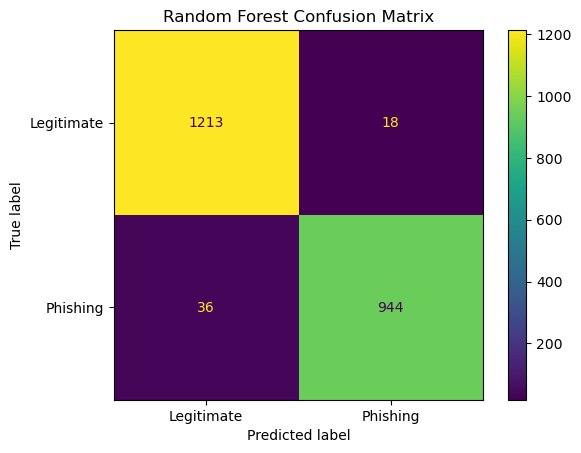

In [ ]:
# Confusion Matrix - Test Set
cm = confusion_matrix(y_test, y_pred_rf_test, labels=[1, -1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

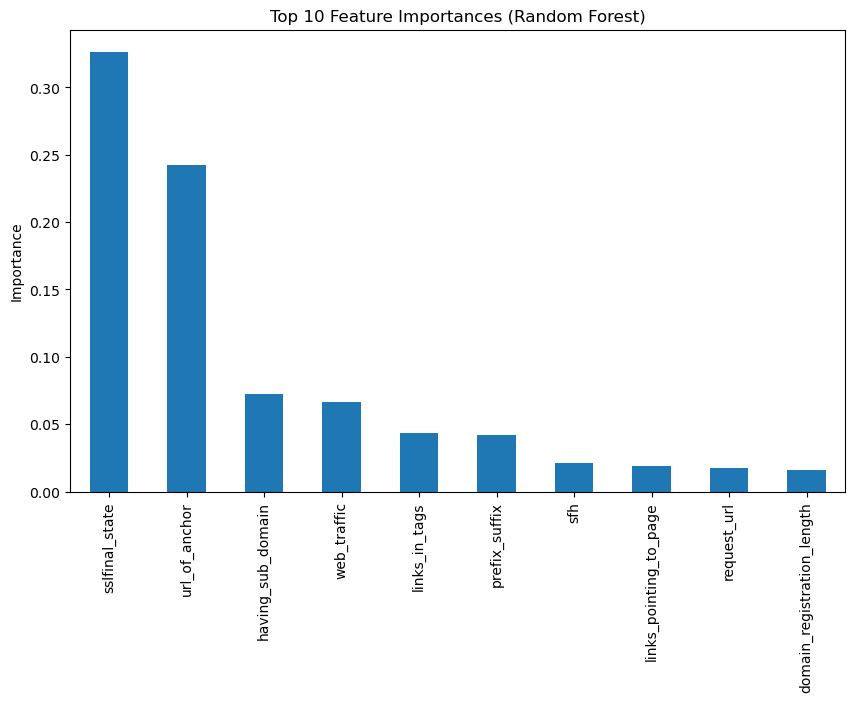

In [5]:
# 10 most important features for Random Forest
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

# XGBoost
----------------------------------------------------------------------------------------------------------------------------------------

In [5]:
# XGBoost with regularization and early stopping to prevent overfitting
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,  # Slower learning to allow generalization
    subsample=0.8,  # Use 80% of samples per tree
    colsample_bytree=0.8,  # Use 80% of features per tree
    reg_lambda=1.0,  # L2 regularization
    reg_alpha=0.5,  # L1 regularization
    random_state=random_seed,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='logloss'
)

# Fit with early stopping using validation set
xgb.fit(X_train, y_train_binary, 
        eval_set=[(X_val, y_val_binary)],
        verbose=False)

# Training, validation, and test predictions
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_val = xgb.predict(X_val)
y_pred_xgb_test = xgb.predict(X_test)

# Calculate accuracies
train_acc = accuracy_score(y_train_binary, y_pred_xgb_train)
val_acc = accuracy_score(y_val_binary, y_pred_xgb_val)
test_acc = accuracy_score(y_test_binary, y_pred_xgb_test)

print(f"XGBoost - Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}, Test Accuracy: {test_acc:.4f}")
print(f"Overfitting Gap (Train - Test): {train_acc - test_acc:.4f}")

XGBoost - Train Accuracy: 0.9789, Val Accuracy: 0.9625, Test Accuracy: 0.9697
Overfitting Gap (Train - Test): 0.0092


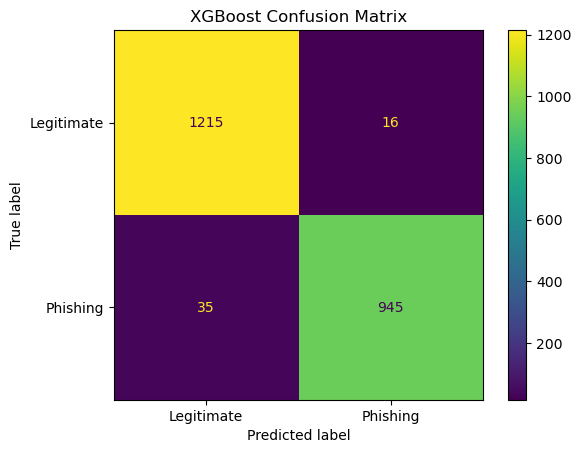

In [ ]:
# Confusion Matrix - Test Set
cm = confusion_matrix(y_test_binary, y_pred_xgb_test, labels=[1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("XGBoost Confusion Matrix (Test Set)")
plt.show()

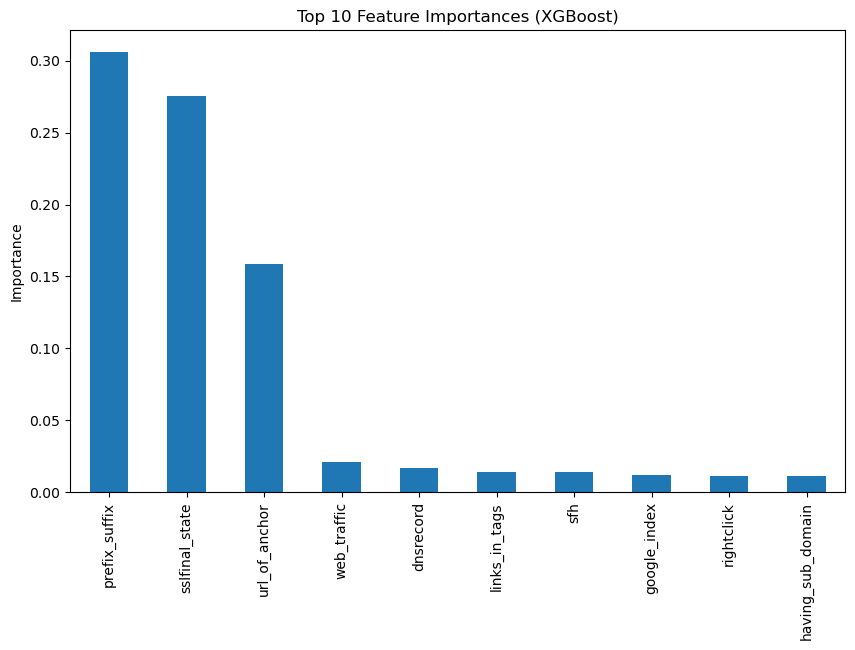

In [8]:
# 10 most important features for XGBoost
importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (XGBoost)")
plt.ylabel("Importance")
plt.show()

# Logistic Regression
----------------------------------------------------------------------------------------------------------------------------------------

In [6]:
# Scaling is highly recommended for logistic regression (Gradient Descent converges faster)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with L2 regularization to prevent overfitting
lr = LogisticRegression(
    solver='liblinear',
    fit_intercept=True,
    C=0.1,  # Lower C = stronger regularization
    penalty='l2',  # L2 (Ridge) regularization
    random_state=random_seed,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train_binary)

# Training, validation, and test predictions
y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_val = lr.predict(X_val_scaled)
y_pred_lr_test = lr.predict(X_test_scaled)

# Calculate accuracies
train_acc = accuracy_score(y_train_binary, y_pred_lr_train)
val_acc = accuracy_score(y_val_binary, y_pred_lr_val)
test_acc = accuracy_score(y_test_binary, y_pred_lr_test)

print(f"Logistic Regression - Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}, Test Accuracy: {test_acc:.4f}")
print(f"Overfitting Gap (Train - Test): {train_acc - test_acc:.4f}")

Logistic Regression - Train Accuracy: 0.9313, Val Accuracy: 0.9199, Test Accuracy: 0.9308
Overfitting Gap (Train - Test): 0.0005


c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


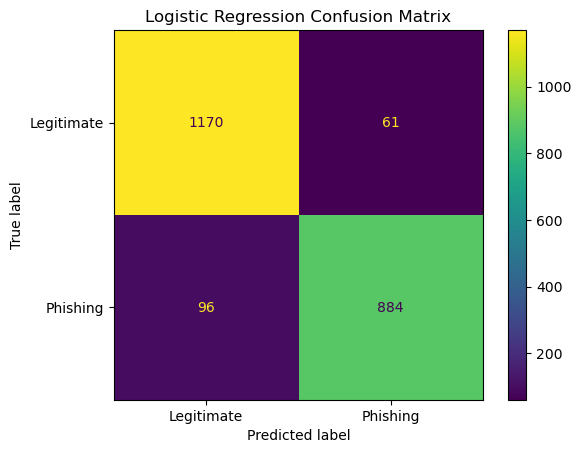

In [ ]:
# Confusion Matrix - Test Set
cm = confusion_matrix(y_test_binary, y_pred_lr_test, labels=[1, 0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("Logistic Regression Confusion Matrix (Test Set)")
plt.show()

In [12]:
coeffs = pd.Series(
    lr.coef_[0],
    index=X.columns
).sort_values()

# Top phishing indicators (positive coefficients)
coeffs.tail(10)

dnsrecord                 0.462796
having_sub_domain         0.485874
links_pointing_to_page    0.486165
having_ip_address         0.576810
web_traffic               0.607842
links_in_tags             0.628955
sfh                       0.642820
sslfinal_state            1.438771
prefix_suffix             2.084951
url_of_anchor             2.289976
dtype: float64

Model Comparison (Lower Train-Test Gap = Less Overfitting):
              Model  Train Accuracy  Validation Accuracy  Test Accuracy
      Random Forest        0.973466             0.957485       0.962460
            XGBoost        0.978893             0.962460       0.969697
Logistic Regression        0.931253             0.919946       0.930801

Overfitting Gaps (Train - Test):
Random Forest: 0.0110
XGBoost: 0.0092
Logistic Regression: 0.0005


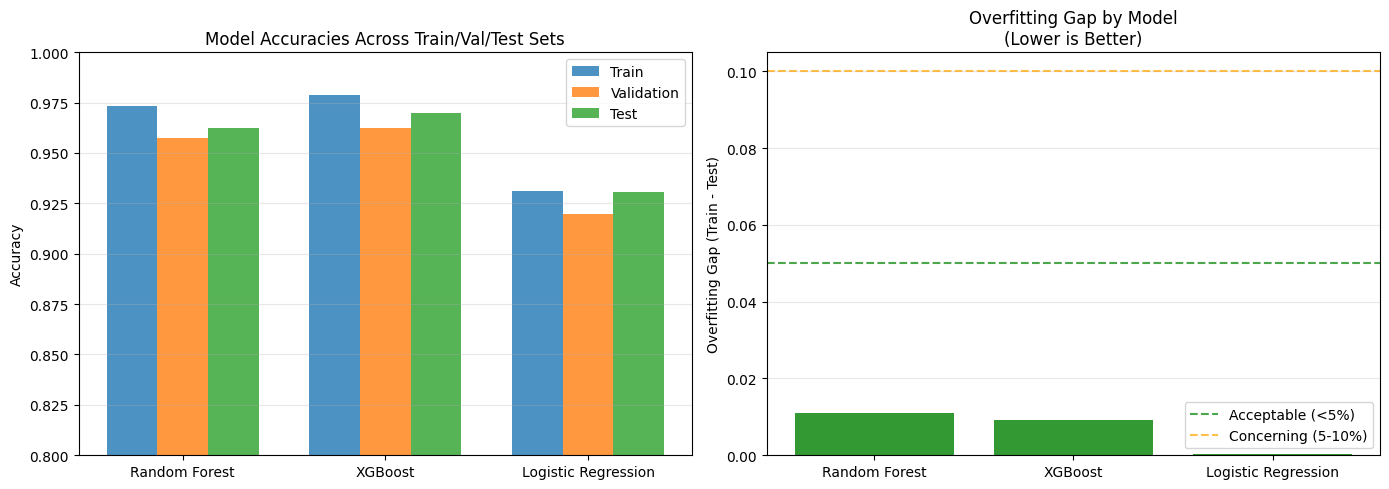

In [7]:
# Calculate accuracies for all models for comparison
models_data = {
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Train Accuracy': [
        accuracy_score(y_train, y_pred_rf_train),
        accuracy_score(y_train_binary, y_pred_xgb_train),
        accuracy_score(y_train_binary, y_pred_lr_train)
    ],
    'Validation Accuracy': [
        accuracy_score(y_val, y_pred_rf_val),
        accuracy_score(y_val_binary, y_pred_xgb_val),
        accuracy_score(y_val_binary, y_pred_lr_val)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_rf_test),
        accuracy_score(y_test_binary, y_pred_xgb_test),
        accuracy_score(y_test_binary, y_pred_lr_test)
    ]
}

comparison_df = pd.DataFrame(models_data)
print("Model Comparison (Lower Train-Test Gap = Less Overfitting):")
print(comparison_df.to_string(index=False))
print("\nOverfitting Gaps (Train - Test):")
for model in comparison_df['Model']:
    idx = comparison_df[comparison_df['Model'] == model].index[0]
    gap = comparison_df.loc[idx, 'Train Accuracy'] - comparison_df.loc[idx, 'Test Accuracy']
    print(f"{model}: {gap:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All accuracies by model
x = np.arange(len(comparison_df['Model']))
width = 0.25

axes[0].bar(x - width, comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
axes[0].bar(x, comparison_df['Validation Accuracy'], width, label='Validation', alpha=0.8)
axes[0].bar(x + width, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracies Across Train/Val/Test Sets')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].set_ylim([0.8, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Overfitting gap (lower is better)
gaps = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']
colors = ['green' if gap < 0.05 else 'orange' if gap < 0.10 else 'red' for gap in gaps]
axes[1].bar(comparison_df['Model'], gaps, color=colors, alpha=0.8)
axes[1].set_ylabel('Overfitting Gap (Train - Test)')
axes[1].set_title('Overfitting Gap by Model\n(Lower is Better)')
axes[1].axhline(y=0.05, color='green', linestyle='--', label='Acceptable (<5%)', alpha=0.7)
axes[1].axhline(y=0.10, color='orange', linestyle='--', label='Concerning (5-10%)', alpha=0.7)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Model Comparison: Overfitting Analysis
------------------------------------------------------------------------

# Random Forest With Only Main Features
----------------------------------------------------------------------------

In [ ]:
main_features = ['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain']

# ensures random sequence is deterministic and reproducible
random_seed = 42

X_train_main = X_train[main_features]
X_val_main = X_val[main_features]
X_test_main = X_test[main_features]

# Regularized Random Forest with main features only
rf_main = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,  # Limit tree depth
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=random_seed,
    n_jobs=-1
)

rf_main.fit(X_train_main, y_train)

# Training, validation, and test predictions
y_pred_rf_main_train = rf_main.predict(X_train_main)
y_pred_rf_main_val = rf_main.predict(X_val_main)
y_pred_rf_main_test = rf_main.predict(X_test_main)

# Calculate accuracies
train_acc = accuracy_score(y_train, y_pred_rf_main_train)
val_acc = accuracy_score(y_val, y_pred_rf_main_val)
test_acc = accuracy_score(y_test, y_pred_rf_main_test)

print(f"Main Feature Random Forest - Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}, Test Accuracy: {test_acc:.4f}")
print(f"Overfitting Gap (Train - Test): {train_acc - test_acc:.4f}")

Main Feature Random Forest Accuracy: 0.7304387155133424


In [30]:
with open("url_features_model.pkl", "wb") as f:
    pickle.dump(rf_main, f)